In [55]:
from config import *
import pandas as pd
import numpy as np
from IPython.display import display
pd.set_option('display.max_colwidth', None)
import matplotlib.pyplot as plt
plt.style.use('default')


Nate Lewin
FTMBA Class of 2027, UC Berkeley Haas
linkedin.com/in/njlewin/
github.com/njlewin/ 

# Executive Summary

# Introduction
For most of the NFL's history, the overtime decision was straightforward: if you win the coin toss, choose to receive. Under pure sudden death rules, in place until 2012, the first score ended the game outright whether it was a touchdown or a field goal. Having the first opportunity to score was an unquestioned advantage. Eventually, games decided by a sudden death field goal were deemed anticlimactic and unfair to the losing team, prompting a rule change. Beginning in 2012, a touchdown on the first drive would still end the game immediately, but a field goal would give the opposing team the opportunity to respond. The receiving team retained a clear advantage.

High-profile overtimes continued to draw criticism, particularly when dramatic offensive duels ended with only one team touching the ball in overtime. The 2021 AFC Championship Game between the Chiefs and Bills, marked by Patrick Mahomes engineering a historic game-tying drive with 13 seconds remaining, ended when the Chiefs scored a touchdown on the opening overtime drive, never giving Josh Allen and the Bills an opportunity to respond. To address this, and to offset the increasing likelihood of scoring drives as kickoff rules gave teams better starting field position, the NFL adopted a new rule guaranteeing both teams a possession regardless of the opening score, first in the playoffs starting in 2023 and then league-wide in 2025.

The advantage under the new rules is no longer clear. The receiving team scores first and gets the first opportunity to end the game after both teams possess the ball and the game is effectively sudden death. But the kicking team has the advantage of information: they know exactly what they need to do based on what the receiving team accomplished on first possession. If the receiving team scores a touchdown, the kicking team knows it must convert on fourth downs to stay alive. If they settle for a field goal, the kicking team knows a field goal ties and a touchdown wins.

The tension between these advantages was on full display at Super Bowl LVIII, the first game played under the new rules. The 49ers won the coin toss and opted to receive, and the Chiefs were visibly surprised, as receiving was their preferred outcome as well. "They want it, they can have it," Chiefs tight end Travis Kelce told his sideline after the toss. The Chiefs won the game with a touchdown after the 49ers scored a field goal. After the first full regular season under these rules in 2025, NFL teams remained split on the decision. With only 17 games played with the new rules providing insufficient data to draw conclusions, this paper uses Monte Carlo simulation of NFL overtime periods to provide an answer on what is the optimal decision between kicking and receiving in the new overtime rules. In addition, it  examines the secondary question of whether the kicking team should play aggressively for the win or accept a tie to extend play on a matching drive.


# Methodology
The model simulates NFL overtime periods using historical play-by-play data, tracking game state and applying the relevant ruleset to determine when the game ends and which team won. The goal is to find a random historical outcome analogous to the game situation, and iterate until the game is complete from the overtime rules. By repeating the random simulations enough (10,000 for our purposes), the results will show the long run average result.

Overtime play is broken into two components: kickoffs and drives. Kickoff results are modeled by sampling randomly from historical kickoffs in the relevant season, producing either a starting field position for the receiving team or a return touchdown. Only kickoffs from the season being modeled are used to account for the frequent rule changes affecting kickoff yard line, touchback location, and the 2024 dynamic kickoff format.

Drives are modeled by matching the current game state to historical drives using weighted Euclidean distance across three variables: starting yard line, time remaining, and score differential. Yard line and time remaining are normalized by their standard deviation within the dataset; score differential is normalized by 7, the practical maximum in overtime. Yard line and time remaining are weighted more heavily than score differential given the constrained range of score differentials in overtime. The 50 closest historical drives are identified as candidates and one is selected at random, introducing variance in outcomes. Drive results include touchdowns, field goals, turnovers (punt, interception, fumble, downs, blocked kick), and return touchdowns on turnovers. Following touchdowns, extra points and two-point conversions are modeled at their historical conversion rates of 96.8% and 48.0% respectively. Following turnovers, the opponent begins their next drive where the subsequent drive began historically.

$$ Score = \sqrt{0.4 \cdot \left(\frac{\Delta\text{yardline}}{\sigma_{\text{yardline}}}\right)^2 + 0.4 \cdot \left(\frac{\Delta\text{time}}{\sigma_{\text{time}}}\right)^2 + 0.2 \cdot \left(\frac{\Delta\text{score differential}}{7}\right)^2}$$

Two decision overrides are applied to account for the strategic differences between regulation and overtime. First, if a sampled drive would result in a punt or field goal that would immediately end the game by overtime rules, the outcome is replaced with a fourth down attempt. The yards-to-go is recorded and matched to a random historical fourth down attempt of similar distance; if successful, a new drive is sampled from the resulting field position to continue the possession. If it fails, possession changes. Second, a configurable flag controls whether a team plays aggressively for the win or accepts ties to extend play — specifically whether to attempt a two-point conversion when trailing by one point after a touchdown, or to go for it on fourth down rather than kick a tying field goal when trailing by three points. Both flags are separate to evaluate the impact on win percentage of each decision separately.

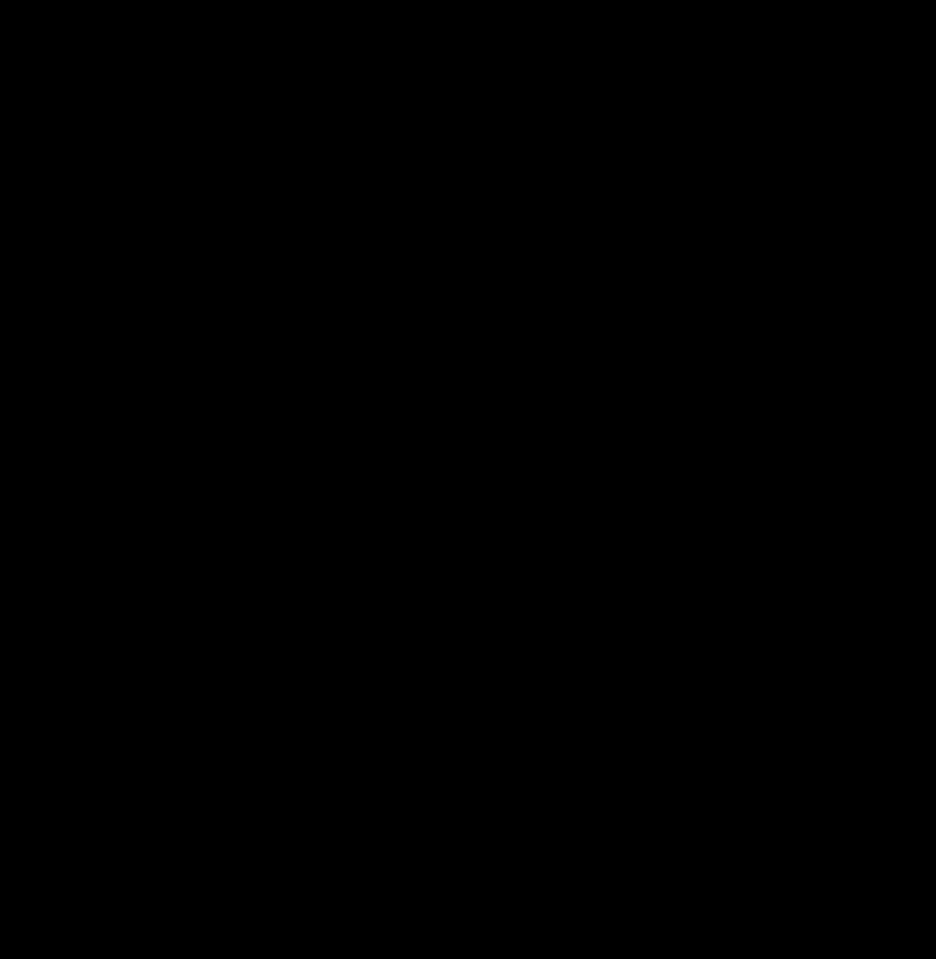
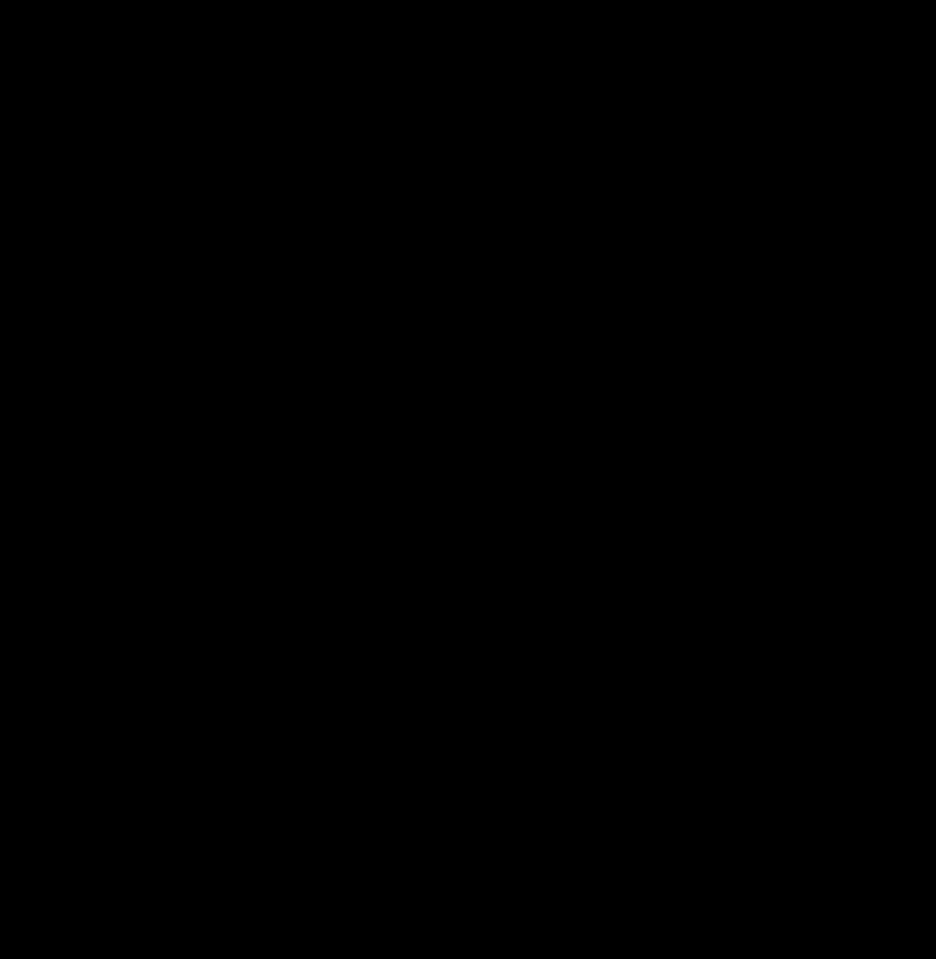
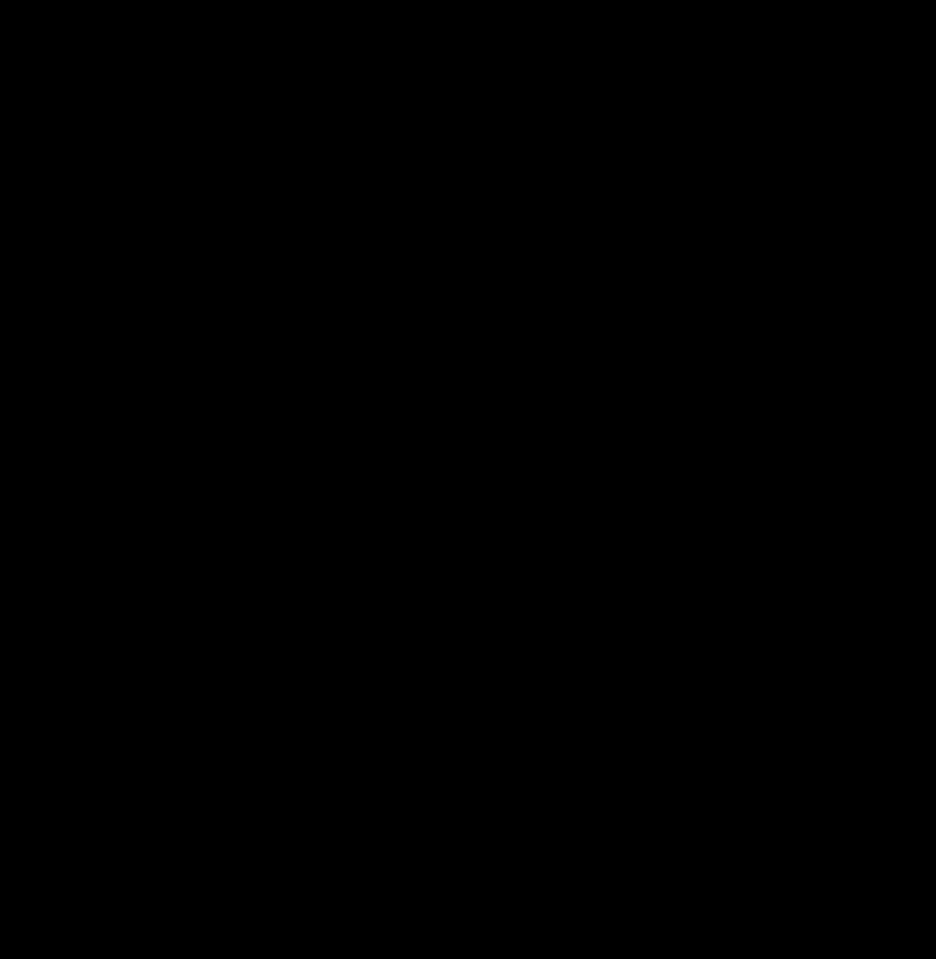
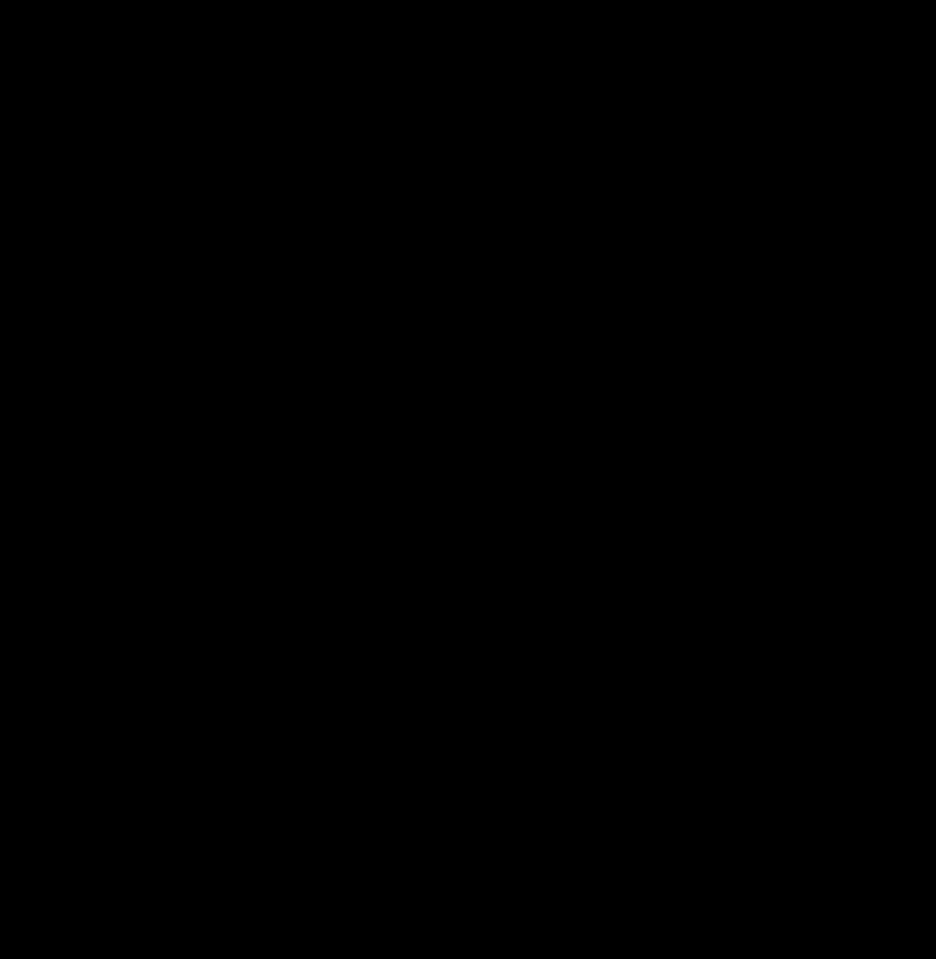

# Results
## Comparison to Historical

To evalualate model accuracy, a represenatative sample of 6 eras to account for all of the overtime rule changes was selected, along with changes to kickoff rules, as starting field position has a high impact on liklihood of scoring on initial drives.


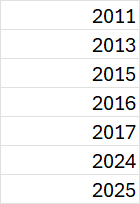

In [2]:
rulesets = pd.read_csv(ASSET_DIR/'overtime_rulesets.csv')
display(rulesets.style.hide(axis='index'))

Ruleset,Overtime Rules,Overtime Length,Kickoff Rules,Avg. Receiving Team Start
Pre 2012,Pure Sudden Death,15 minutes,"Kickoff at the 35 Yardline, Touchback at the 20 Yardline",28
2012-2015,"Sudden Death, except for a first possession field goal",15 minutes,"Kickoff at the 35 Yardline, Touchback at the 20 Yardline",23
2016,"Sudden Death, except for a first possession field goal",15 minutes,"Kickoff at the 35 Yardline, Touchback at the 25 Yardline",26
2017-2023,"Sudden Death, except for a first possession field goal",10 minutes,"Kickoff at the 35 Yardline, Touchback at the 25 Yardline",26
2024,"Sudden Death, except for a first possession field goal",10 minutes,"Dynamic Kickoff Rules, Touchback at the 30 Yardline",30
2025,Both Teams Guaranteed one possession,10 minutes,"Dynamic Kickoff Rules, Touchback at the 35 yard line",31


The model was run for a season representative of each ruleset and compared to historical results. To align with traditionally conservative strategy of NFL teams, all simulations go for game-tying field goals and extra points.

In [28]:
hist_results = pd.read_csv(ASSET_DIR/HIST_COMPARISON)
flat_cols = hist_results.columns
hist_results.columns = pd.MultiIndex.from_tuples([
    (('Historical', c.replace(' Historical', '')) if 'Historical' in c
     else ('Modeled', c.replace(' Modeled', '')) if 'Modeled' in c
     else ('', c))
    for c in flat_cols
])
pct_cols = [(g, c) for g, c in hist_results.columns
            if pd.api.types.is_numeric_dtype(hist_results[g, c]) and hist_results[g, c].abs().between(0, 1).all()]
hist_results.style \
    .format({c: '{:.2%}' for c in pct_cols}) \
    .apply_index(lambda s: ['background-color: #1a3a5c; color: white' if v == 'Historical'
                             else 'background-color: #1a5c2a; color: white' if v == 'Modeled'
                             else '' for v in s], axis='columns', level=0) \
    .set_table_styles([{'selector': 'th.col_heading.level0', 'props': [('text-align', 'center')]}]).hide(axis='index')

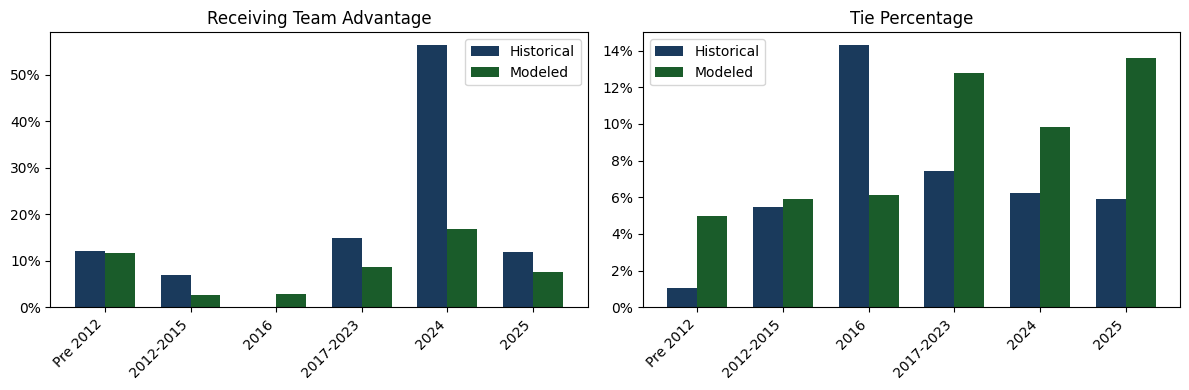

In [67]:
import numpy as np

rulesets = hist_results['', 'ruleset'].tolist()
x = np.arange(len(rulesets))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for ax, hist_col, mod_col, title in [
    (ax1, ('Historical', 'Receiving Team Advantage'), ('Modeled', 'Receiving Team Advantage'), 'Receiving Team Advantage'),
    (ax2, ('Historical', '% Tie'),                   ('Modeled', '% Tie'),                    'Tie Percentage')
]:
    ax.bar(x - width/2, hist_results[hist_col], width, label='Historical', color='#1a3a5c')
    ax.bar(x + width/2, hist_results[mod_col],  width, label='Modeled',    color='#1a5c2a')
    ax.set_xticks(x)
    ax.set_xticklabels(rulesets, rotation=45, ha='right')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.set_title(title)
    ax.legend()
    ax.axhline(0, linewidth=0.5)

plt.tight_layout()
plt.show()

## 2025 Rules Impact
* Receiving team is advantaged because each possession is less likely to occur than the previous
* Two guaranteed posessions is 50/50-ish, slight advantage to kicking team (due to information)
* Third possession will result in a win for the receiving team or tie
* Fourth possession will win for the kicking team, but less likely to occur.
* Opt to receive to get the third possession. 50/50 on the first possession. X% likely to win after that.

## Kicking Team Decision Making
* Go for two on tying TDs, otherwise giving them the first crack at sudden death. Takes win equity from ties to receiving team. 50% chance to win now is better than odds on possession 3.
* Field goals are more complicated. As a whole going for fourth downs instead of tying field goals adds win percentage to the receiving team, opposite of what we are expecting. This is because the 50/50 result of the 4DA doesn't nessecarily reuslt in a win if sucessful, only a certain percentage will result in a TD, otherwise it will result in another 4th down attempt (assume punts out while you are in FG range and turnovers sufficiently unlikely). Can draw out decision tree.
* Odds tip at teh 25 yard line.

# Conclusion
* Restate conclusions (Receiving team advantage, kicking team should be selectively aggressive)
* Note the advantages are small, game context and team should influence decisions, though you should feel strongly to override 5% win percentage of receiving.
* Note the power of this structure for modeling large amounts of NFL periods.

In [66]:
%%capture
import nbformat
from nbconvert import HTMLExporter
from pathlib import Path
nb = nbformat.read("NFL_Overtime_Model.ipynb", as_version=4)
exporter = HTMLExporter(exclude_input=True, exclude_output_prompt=True)
html, _ = exporter.from_notebook_node(nb)
html = html.replace("<title>Notebook</title>", "<title>NFL Overtime Model</title>")
html = html.replace("</head>", """<style>
table { margin: 0 auto; }
.jp-OutputArea-output { display: flex; justify-content: center; }
body { padding: 0 40px; }
</style></head>""")
Path("index.html").write_text(html, encoding="utf-8")